In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

df_pokemon = pd.read_csv('pokemon.csv')
df_combats = pd.read_csv('combats.csv')
print(df_pokemon.info())
display(df_pokemon.head())

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        799 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB
None


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [55]:
df_pokemon.loc[df_pokemon['#'] == 63, 'Name'] = 'Primeape'
df_pokemon['Type 2'] = df_pokemon['Type 2'].fillna('None')
print(df_pokemon.info())

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      800 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB
None


In [56]:
wins = df_combats.groupby('Winner').size().rename('wins')

total_battles = pd.concat([
    df_combats['First_pokemon'],
    df_combats['Second_pokemon']
]).value_counts().rename('total_battles')

win_rate = pd.concat([wins, total_battles], axis=1)
win_rate['wins'] = win_rate['wins'].fillna(0)
win_rate['win_pct'] = win_rate['wins'] / win_rate['total_battles'] * 100
win_rate = win_rate.sort_values('win_pct', ascending=False)

print(win_rate.head())

      wins  total_battles    win_pct
155  127.0            129  98.449612
513  116.0            119  97.478992
704  121.0            125  96.800000
20   115.0            119  96.638655
154  136.0            141  96.453901


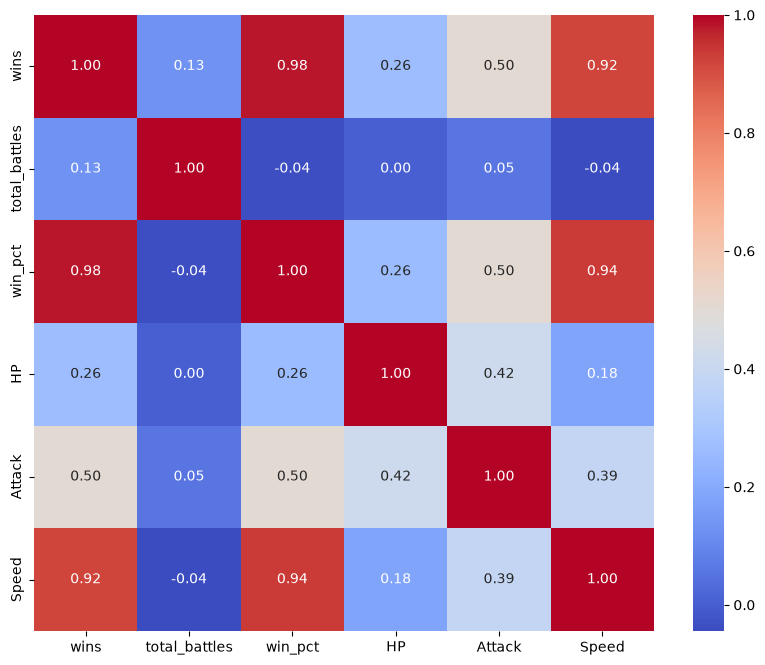

In [57]:
win_rate = win_rate.join(df_pokemon.set_index('#')[['HP', 'Attack', 'Speed']])

plt.figure(figsize=(10, 8))
sns.heatmap(win_rate.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

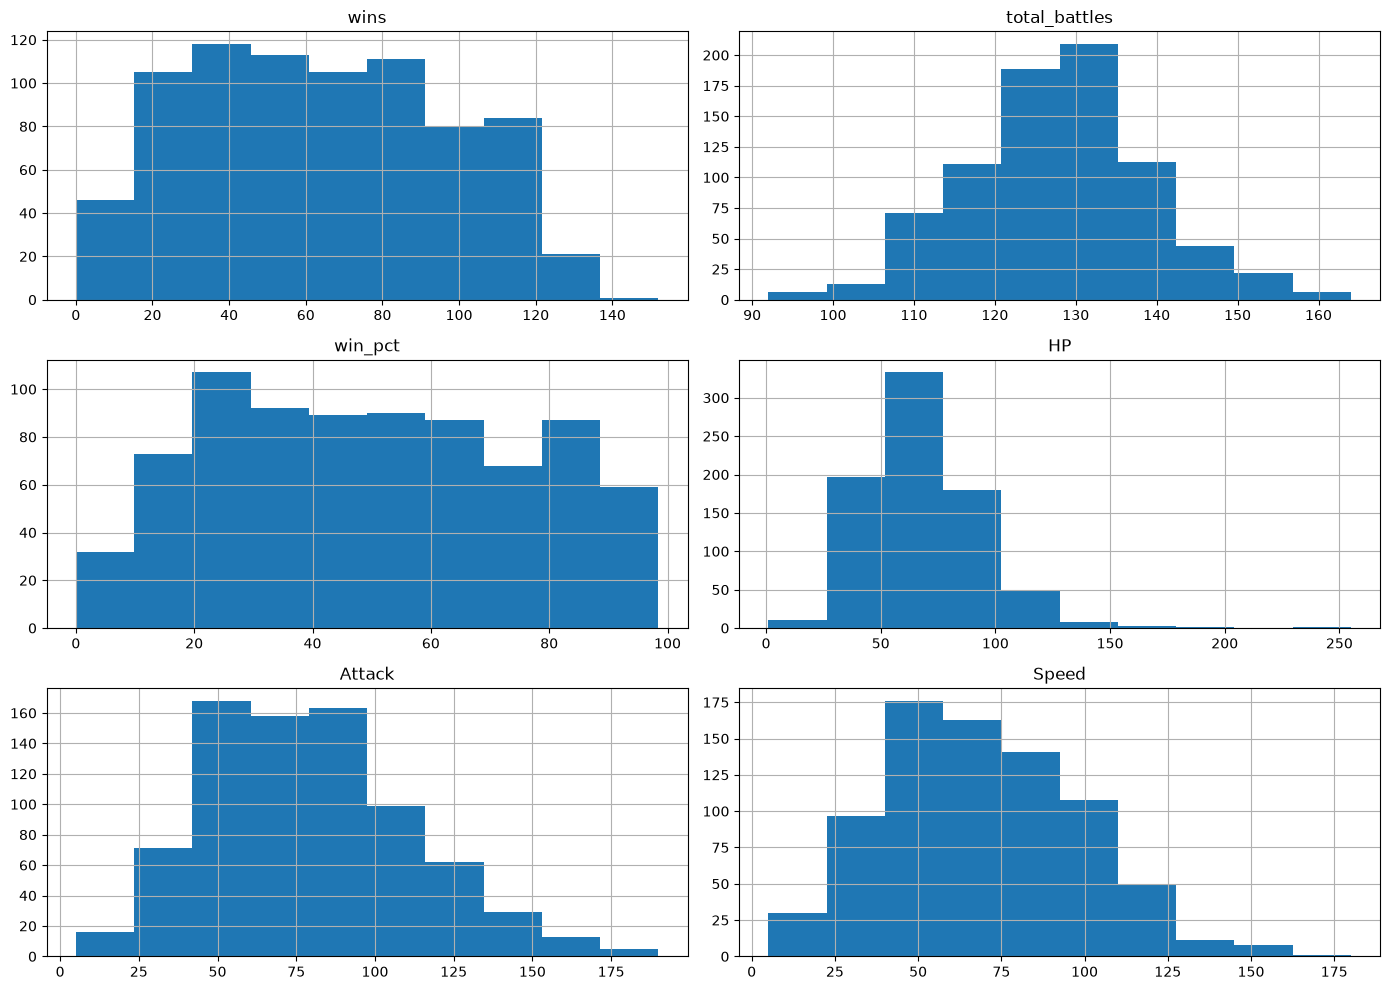

In [58]:
win_rate.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

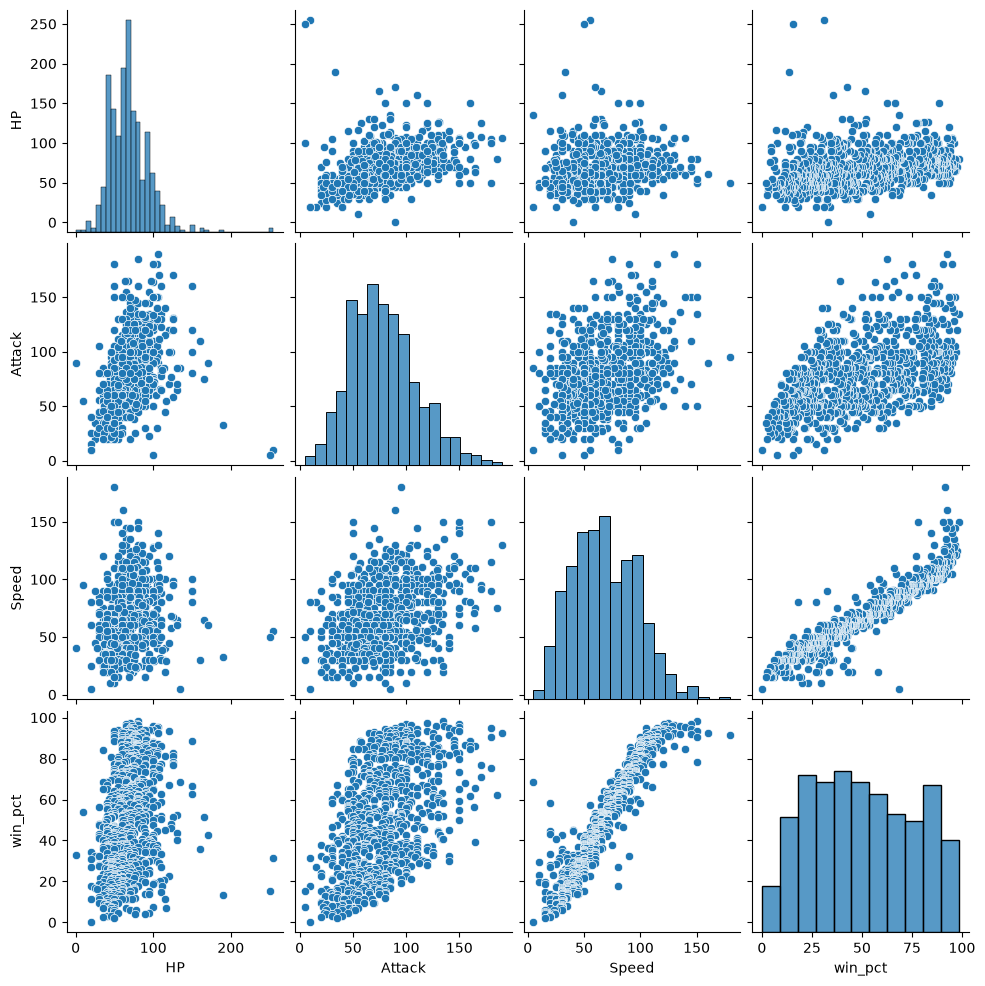

In [59]:
sns.pairplot(win_rate[['HP', 'Attack', 'Speed', 'win_pct']])
plt.show()

In [60]:
top10 = win_rate.sort_values('win_pct', ascending=False).head(10)
top10 = top10.join(df_pokemon.set_index('#')['Name'])
print(top10[['Name', 'win_pct', 'HP', 'Attack', 'Speed']])

                         Name    win_pct   HP  Attack  Speed
155           Mega Aerodactyl  98.449612   80     135    150
513                   Weavile  97.478992   70     120    125
704    Tornadus Therian Forme  96.800000   79     100    121
20              Mega Beedrill  96.638655   65     150    145
154                Aerodactyl  96.453901   80     105    130
477              Mega Lopunny  96.124031   65     136    135
727                  Greninja  96.062992   72      95    122
717  Meloetta Pirouette Forme  95.934959  100     128    128
165             Mega Mewtwo Y  95.200000  106     150    140
350             Mega Sharpedo  95.000000   70     140    105


In [61]:
X = win_rate[['HP', 'Attack', 'Speed']]
y = win_rate['win_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE LinearRegression: {mae:.4f}")

MAE LinearRegression: 5.7748


In [63]:
model2 = RandomForestRegressor(random_state=42)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE RandomForestRegressor: {mae:.4f}")

MAE RandomForestRegressor: 4.2490


In [64]:
model3 = XGBRegressor(random_state=42)
model3.fit(X_train, y_train)
y_pred = model3.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE XGBRegressor: {mae:.4f}")

MAE XGBRegressor: 4.5214
